# Customer Segmentation for Credit Card Customers

**Dataset:** CC GENERAL (Kaggle) — 8,950 credit card holders, 17 behavioral features  
**Goal:** Segment customers into distinct behavioral groups and derive actionable business insights.

---

In [36]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df=pd.read_csv("CC GENERAL.csv")
df_original = df.copy()

df = df.drop(columns=['CUST_ID'])

## Phase 1: Data Exploration & Preprocessing
### 1.1 Dataset Overview
We begin by examining the structure and content of the dataset to understand what each feature represents and catch any immediate data quality issues.

In [38]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [39]:
print(df.shape)
print(df.info())

(8950, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  


> **Insight:** The dataset contains **8,950 customers** and **17 features** covering balance, purchase behavior, cash advances, credit limits, payments, and tenure. All features are numeric — no categorical variables need encoding. This is a well-structured behavioral dataset suitable for unsupervised clustering.

### 1.2 Data Quality Check

In [40]:
duplicates = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

Number of duplicate rows: 0


In [41]:
df.isnull().sum()

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

> **Insight:** The dataset has **no duplicate rows**. Two features have missing values:
> - `MINIMUM_PAYMENTS`: **313 missing** (~3.5%) — the most significant gap.
> - `CREDIT_LIMIT`: **1 missing** — trivially handled with median imputation.
>
> Notably, the missing `MINIMUM_PAYMENTS` rows all have `PAYMENTS = 0`, suggesting these customers made no payments during the period — so a simple mean/median fill would be misleading. A more realistic, rule-based imputation strategy is used below.

In [42]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


> **Insight:** Several features show extreme right skew. For example, `BALANCE` ranges from 0 to ~19,043 and `CASH_ADVANCE` up to ~47,137, with most customers clustered at low values. This confirms the need for log transformation before clustering. `PURCHASES_FREQUENCY` and `PRC_FULL_PAYMENT` are bounded [0,1] frequency/ratio features and are left untransformed.

### 1.3 Feature Distributions

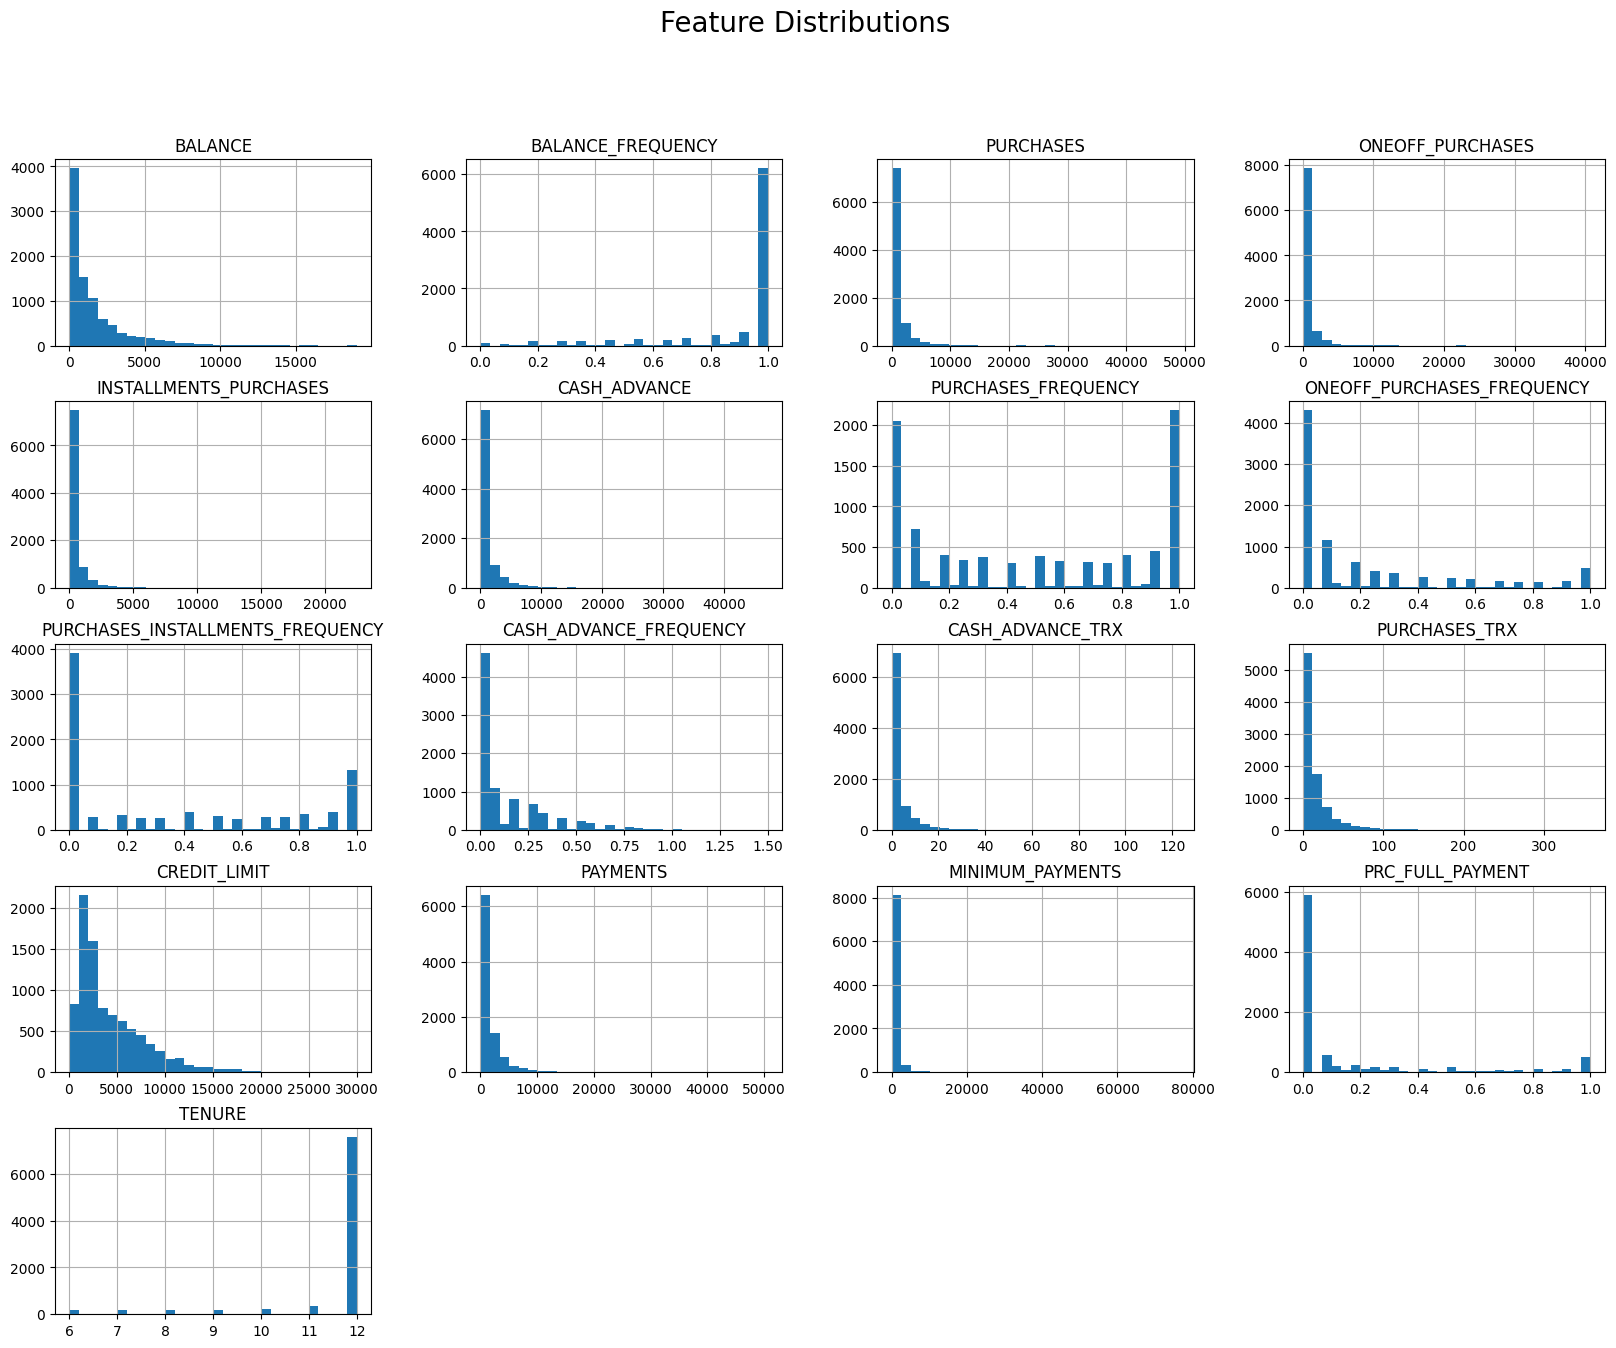

In [43]:
df.hist(bins=30, figsize=(20,15))
plt.suptitle("Feature Distributions", fontsize=20)
plt.show()

> **Insight:** Most monetary features (BALANCE, PURCHASES, CASH_ADVANCE) are highly right-skewed — the majority of customers have low balances and low spending, while a small minority drive very large values. The bimodal pattern in `PURCHASES_FREQUENCY` and `PRC_FULL_PAYMENT` suggests two natural customer archetypes: active purchasers vs. inactive ones, and full-payers vs. revolvers.

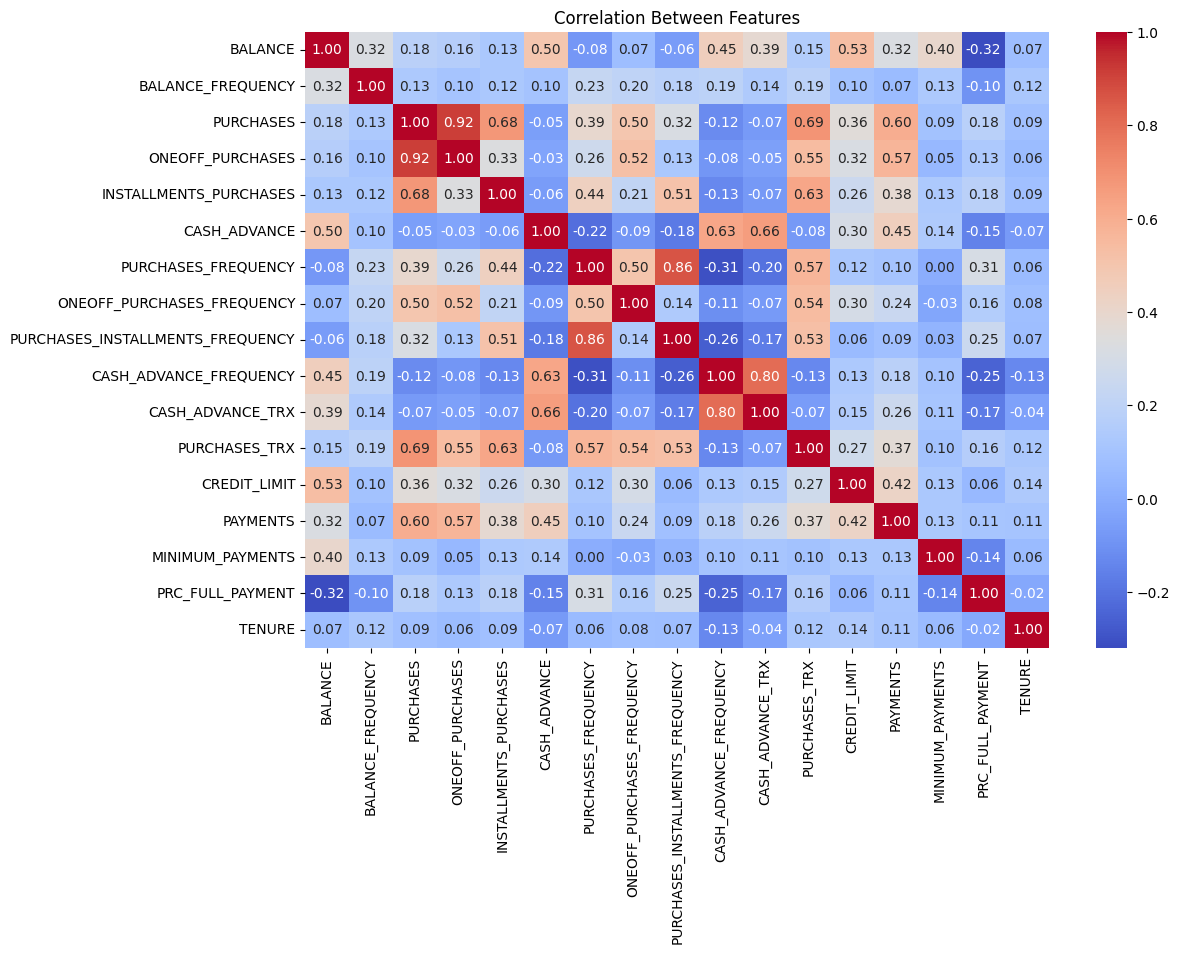

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Between Features")
plt.show()

> **Insight:** The correlation heatmap reveals several strong relationships:
> - `PURCHASES` ↔ `PURCHASES_TRX` (r≈0.69): More purchase transactions → higher total spend.
> - `CASH_ADVANCE` ↔ `CASH_ADVANCE_TRX` (r≈0.65): Cash advance amount scales with frequency.
> - `ONEOFF_PURCHASES` and `INSTALLMENTS_PURCHASES` are largely independent of each other, suggesting two distinct purchase styles that may define separate customer segments.
> - `PRC_FULL_PAYMENT` is negatively correlated with `BALANCE`, confirming that full-payers carry less debt.

### 1.4 Missing Value Imputation
For `CREDIT_LIMIT` (1 missing value), median imputation is applied. For `MINIMUM_PAYMENTS` (313 missing), we use a **rule-based imputation** that mirrors how banks calculate minimum payments — the greater of 3% of balance or 1% of credit limit, subject to a tiered floor based on credit limit tier. Customers with zero balance are assigned a minimum payment of 0.

In [45]:
df = df.assign(CREDIT_LIMIT=df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median()))

pct_balance = df['BALANCE'] * 0.03
pct_credit = df['CREDIT_LIMIT'] * 0.01

calculated_min = np.maximum(pct_balance, pct_credit)

floor_amount = pd.Series(
    np.where(df['CREDIT_LIMIT'] >= 10000, 35,
    np.where(df['CREDIT_LIMIT'] >= 5000, 25, 15)),
    index=df.index
)

realistic_min = pd.Series(
    np.where(
        df['BALANCE'] == 0, 0,
        np.minimum(df['BALANCE'], np.maximum(calculated_min, floor_amount))
    ),
    index=df.index
)

df = df.assign(MINIMUM_PAYMENTS=df['MINIMUM_PAYMENTS'].fillna(realistic_min))


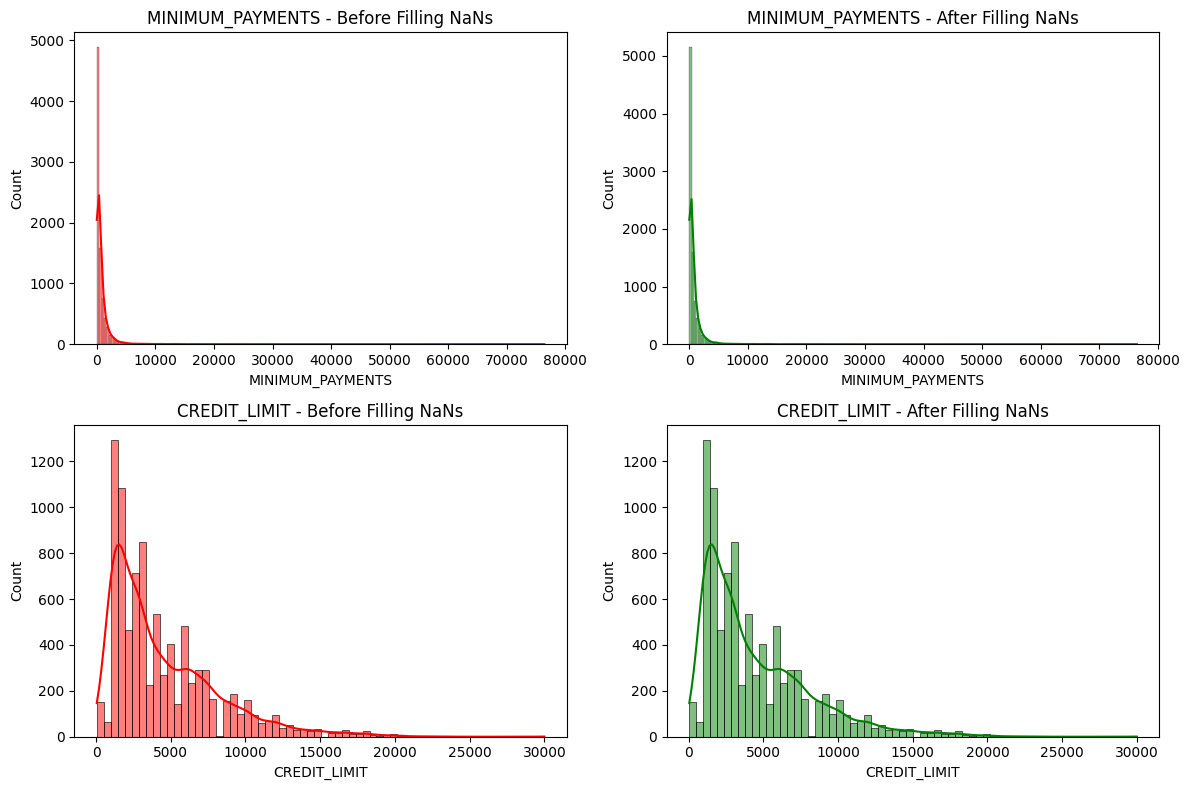

In [46]:
# histograms before and after imputation
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
# MINIMUM_PAYMENTS - Before
sns.histplot(df_original['MINIMUM_PAYMENTS'], kde=True, ax=axs[0, 0], color= 'red')
axs[0, 0].set_title('MINIMUM_PAYMENTS - Before Filling NaNs')
# MINIMUM_PAYMENTS - After
sns.histplot(df['MINIMUM_PAYMENTS'], kde=True, ax=axs[0, 1], color= 'green')
axs[0, 1].set_title('MINIMUM_PAYMENTS - After Filling NaNs')
# CREDIT_LIMIT - Before
sns.histplot(df_original['CREDIT_LIMIT'], kde=True, ax=axs[1, 0], color='red')
axs[1, 0].set_title('CREDIT_LIMIT - Before Filling NaNs')
# CREDIT_LIMIT - After
sns.histplot(df['CREDIT_LIMIT'], kde=True, ax=axs[1, 1], color='green')
axs[1, 1].set_title('CREDIT_LIMIT - After Filling NaNs')
plt.tight_layout()
plt.show()

> **Insight:** The before/after distributions for `MINIMUM_PAYMENTS` are nearly identical — the rule-based imputation preserved the overall shape and scale of the distribution, unlike a naive mean/median fill which would have created an artificial spike. This approach maintains statistical integrity while being grounded in real banking logic.
>
> `CREDIT_LIMIT` distribution is unchanged since only one value was imputed.

In [47]:
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

### 1.5 Handling Skewness — Log Transformation
Monetary features have extreme right skew (values up to 13.8). We apply `log1p` (i.e., log(1+x)) to handle zero values gracefully. Frequency/ratio features (`PURCHASES_FREQUENCY`, `BALANCE_FREQUENCY`, `PRC_FULL_PAYMENT`, etc.) are already bounded [0,1] and are left as-is.

In [48]:
df.skew().sort_values(ascending=False).round(2)

MINIMUM_PAYMENTS                    13.81
ONEOFF_PURCHASES                    10.05
PURCHASES                            8.14
INSTALLMENTS_PURCHASES               7.30
PAYMENTS                             5.91
CASH_ADVANCE_TRX                     5.72
CASH_ADVANCE                         5.17
PURCHASES_TRX                        4.63
BALANCE                              2.39
PRC_FULL_PAYMENT                     1.94
CASH_ADVANCE_FREQUENCY               1.83
ONEOFF_PURCHASES_FREQUENCY           1.54
CREDIT_LIMIT                         1.52
PURCHASES_INSTALLMENTS_FREQUENCY     0.51
PURCHASES_FREQUENCY                  0.06
BALANCE_FREQUENCY                   -2.02
TENURE                              -2.94
dtype: float64

In [49]:
skewed_cols = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
    'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
    'PAYMENTS', 'MINIMUM_PAYMENTS','CREDIT_LIMIT', 'PURCHASES_TRX', 'CASH_ADVANCE_TRX'
]

for col in skewed_cols:
    df = df.assign(**{col: np.log1p(df[col])})

In [50]:
print("\nSkewness after log transform:\n",
      df.skew().sort_values(ascending=False).round(2))


Skewness after log transform:
 PRC_FULL_PAYMENT                    1.94
CASH_ADVANCE_FREQUENCY              1.83
ONEOFF_PURCHASES_FREQUENCY          1.54
CASH_ADVANCE_TRX                    0.94
PURCHASES_INSTALLMENTS_FREQUENCY    0.51
CASH_ADVANCE                        0.26
ONEOFF_PURCHASES                    0.19
PURCHASES_FREQUENCY                 0.06
PURCHASES_TRX                       0.03
INSTALLMENTS_PURCHASES             -0.02
CREDIT_LIMIT                       -0.10
MINIMUM_PAYMENTS                   -0.63
PURCHASES                          -0.76
BALANCE                            -0.86
PAYMENTS                           -1.78
BALANCE_FREQUENCY                  -2.02
TENURE                             -2.94
dtype: float64


> **Insight:** Log transformation dramatically reduced skewness across all monetary features. For example, `MINIMUM_PAYMENTS` dropped from 13.81 to near-zero skew. The remaining mild skew in `PRC_FULL_PAYMENT` (1.94) and `CASH_ADVANCE_FREQUENCY` (1.83) is acceptable — these are ratio features with a natural ceiling of 1, so transformation is not appropriate.

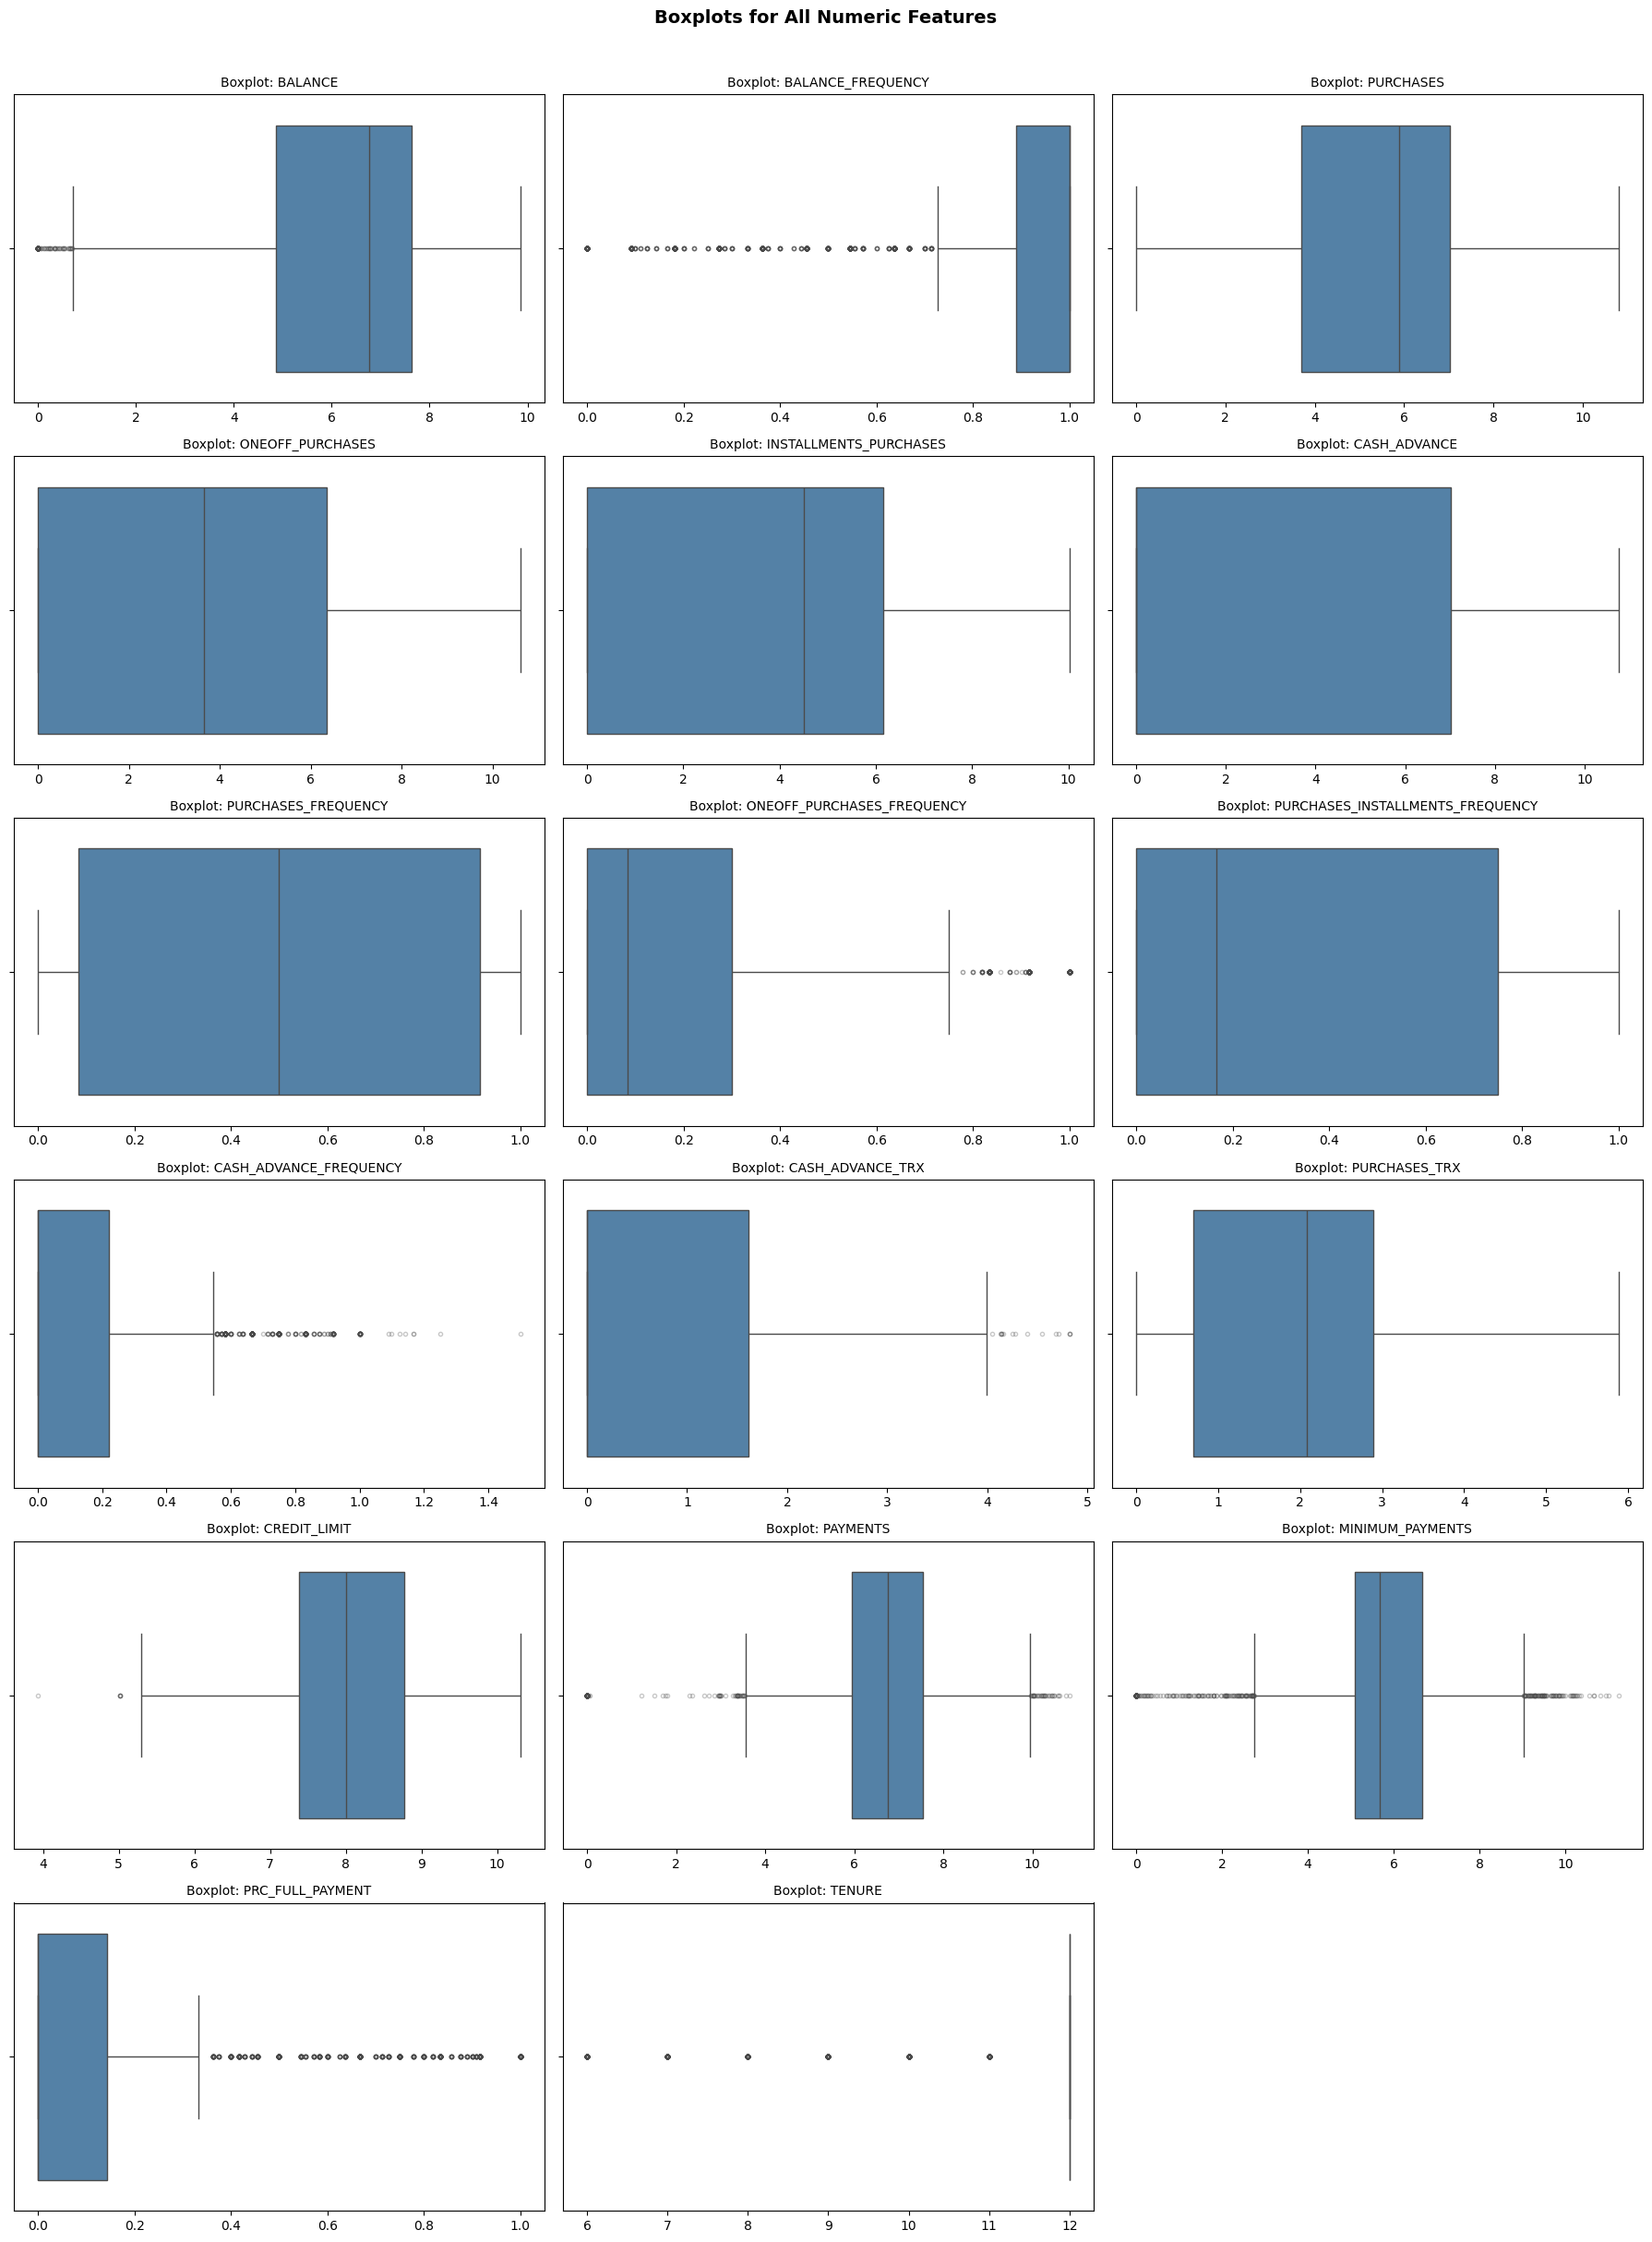

In [51]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, column in enumerate(num_cols):
    sns.boxplot(x=df[column], ax=axes[i], color='steelblue', flierprops={'marker': '.', 'alpha': 0.3})
    axes[i].set_title(f'Boxplot: {column}', fontsize=10)
    axes[i].set_xlabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots for All Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> **Insight:** Boxplots confirm that after transformation, outliers are much less extreme. Some outliers remain (especially in `CASH_ADVANCE_FREQUENCY` and `PRC_FULL_PAYMENT`), but these likely represent genuinely distinct customer behaviors rather than errors.

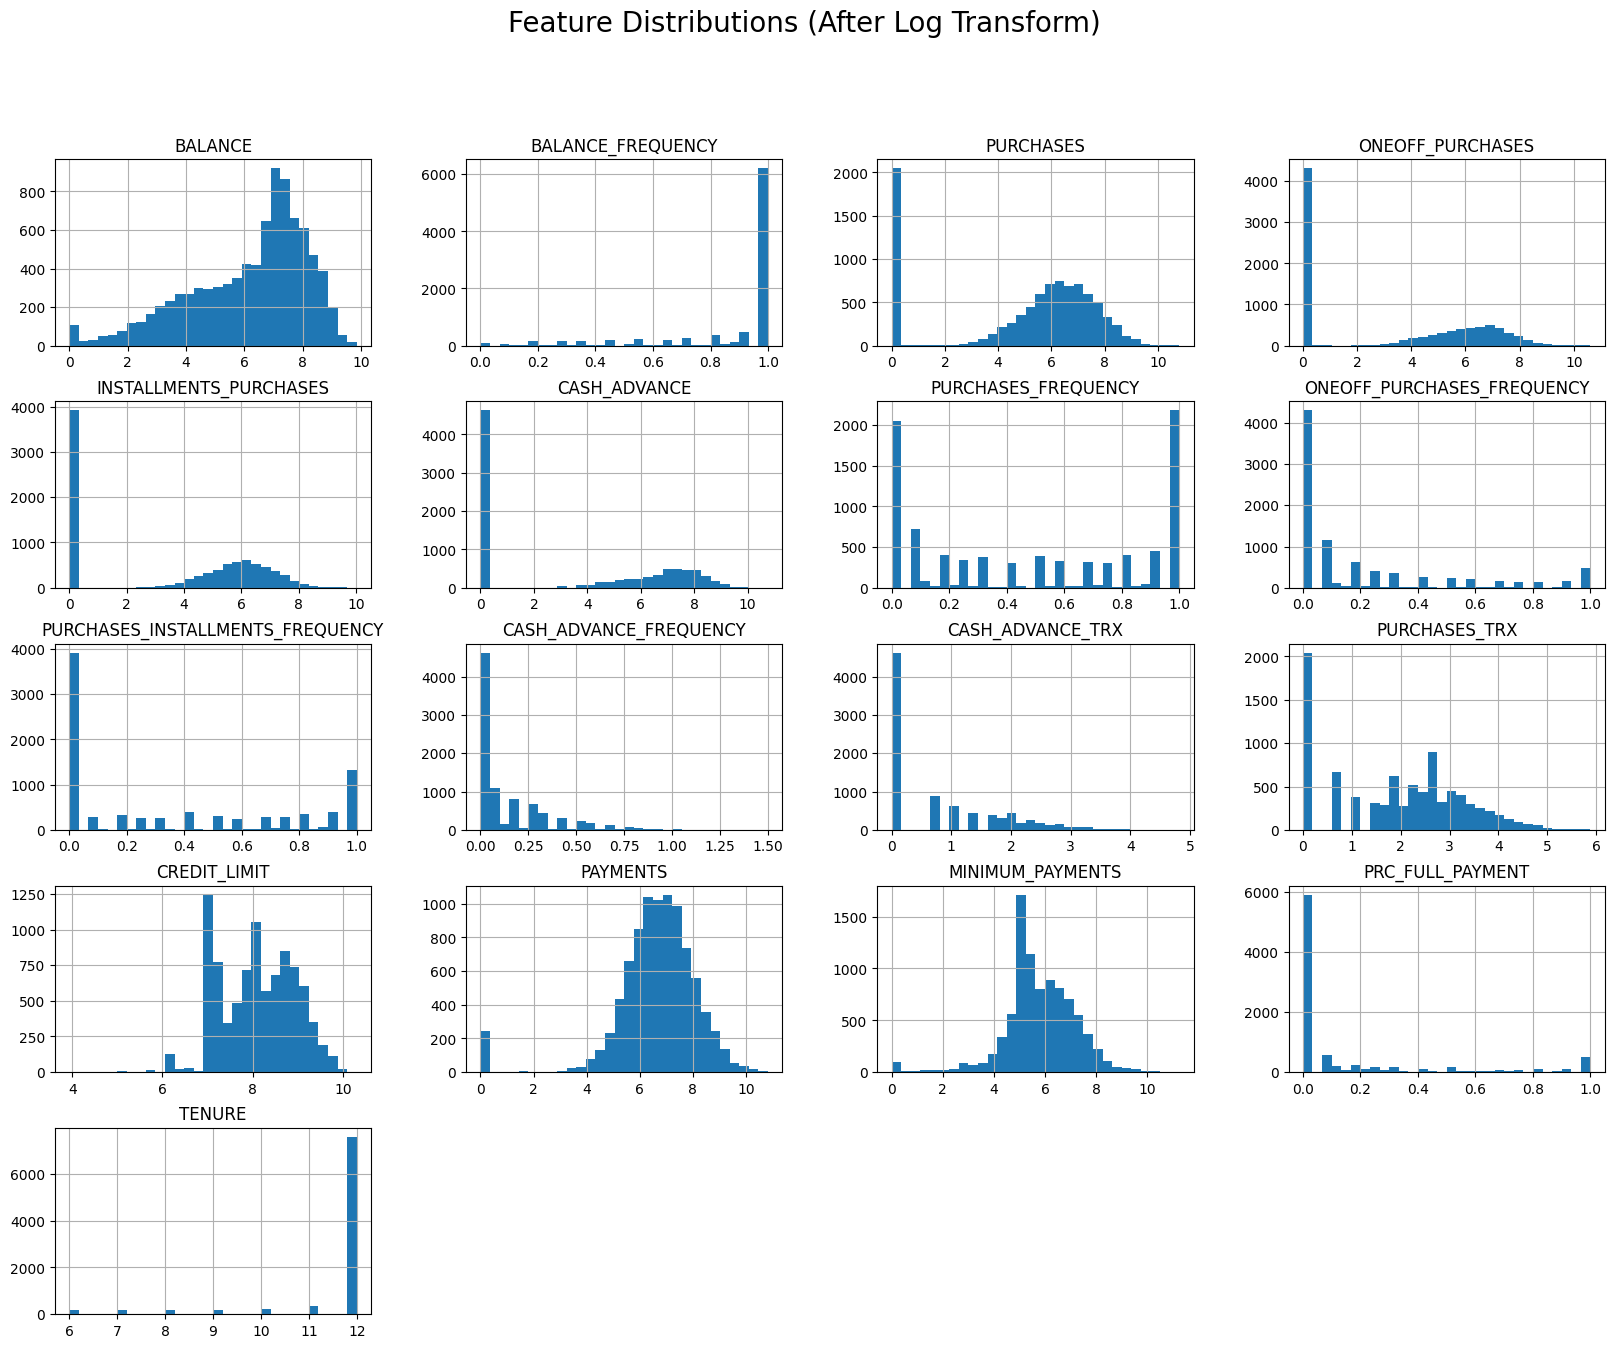

In [52]:
df.hist(bins=30, figsize=(20,15))
plt.suptitle("Feature Distributions (After Log Transform)", fontsize=20)
plt.show()

---
## Phase 2: Determining Optimal Number of Clusters
We test multiple k values using three complementary methods: the **Elbow Method** (WCSS), **Silhouette Score**, and **t-SNE visual inspection**. Both **K-Means** and **Gaussian Mixture Models (GMM)** are evaluated to ensure the choice of k is robust across algorithms.

In [53]:
# Create a clean copy for clustering (excludes Cluster column added later)
df_transformed = df.copy()

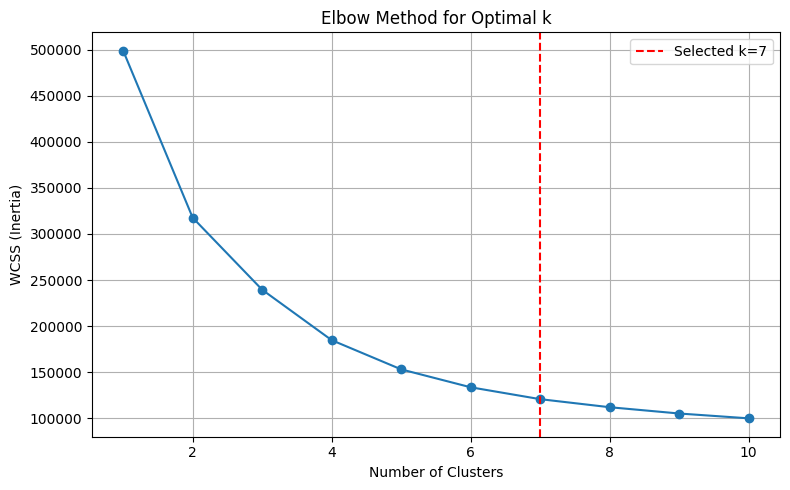

In [54]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000, n_init=10, init='k-means++')
    kmeans.fit(df_transformed)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.axvline(x=7, color='red', linestyle='--', label='Selected k=7')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Inertia)")
plt.title('Elbow Method for Optimal k')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

> **Insight:** The WCSS curve shows a clear initial drop up to k=4, then diminishing returns. There is no single sharp elbow, which is typical for real-world behavioral data. The curve begins to flatten notably around k=6–7, suggesting that additional clusters beyond 7 do not significantly improve compactness. The red line marks our final selection of k=7.

In [55]:
#Silhouette score
for k in range (2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000, n_init=10, init='k-means++')
    kmeans.fit(df_transformed)
    score = silhouette_score(df_transformed, kmeans.labels_)
    print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=2: 0.3522
Silhouette Score for k=3: 0.3577
Silhouette Score for k=4: 0.3762
Silhouette Score for k=5: 0.3967
Silhouette Score for k=6: 0.4071
Silhouette Score for k=7: 0.4232
Silhouette Score for k=8: 0.3944
Silhouette Score for k=9: 0.3239
Silhouette Score for k=10: 0.3175


> **Insight:** Silhouette score peaks at **k=7 (0.4232)** for K-Means. Scores for k=8, 9, 10 drop significantly (0.39, 0.32, 0.32), confirming that k=7 produces the most well-separated, cohesive clusters.

In [56]:
tsne = TSNE(n_components=2, random_state=42, perplexity=100, max_iter=1000, learning_rate='auto', init='pca')
df_tsne = tsne.fit_transform(df_transformed)

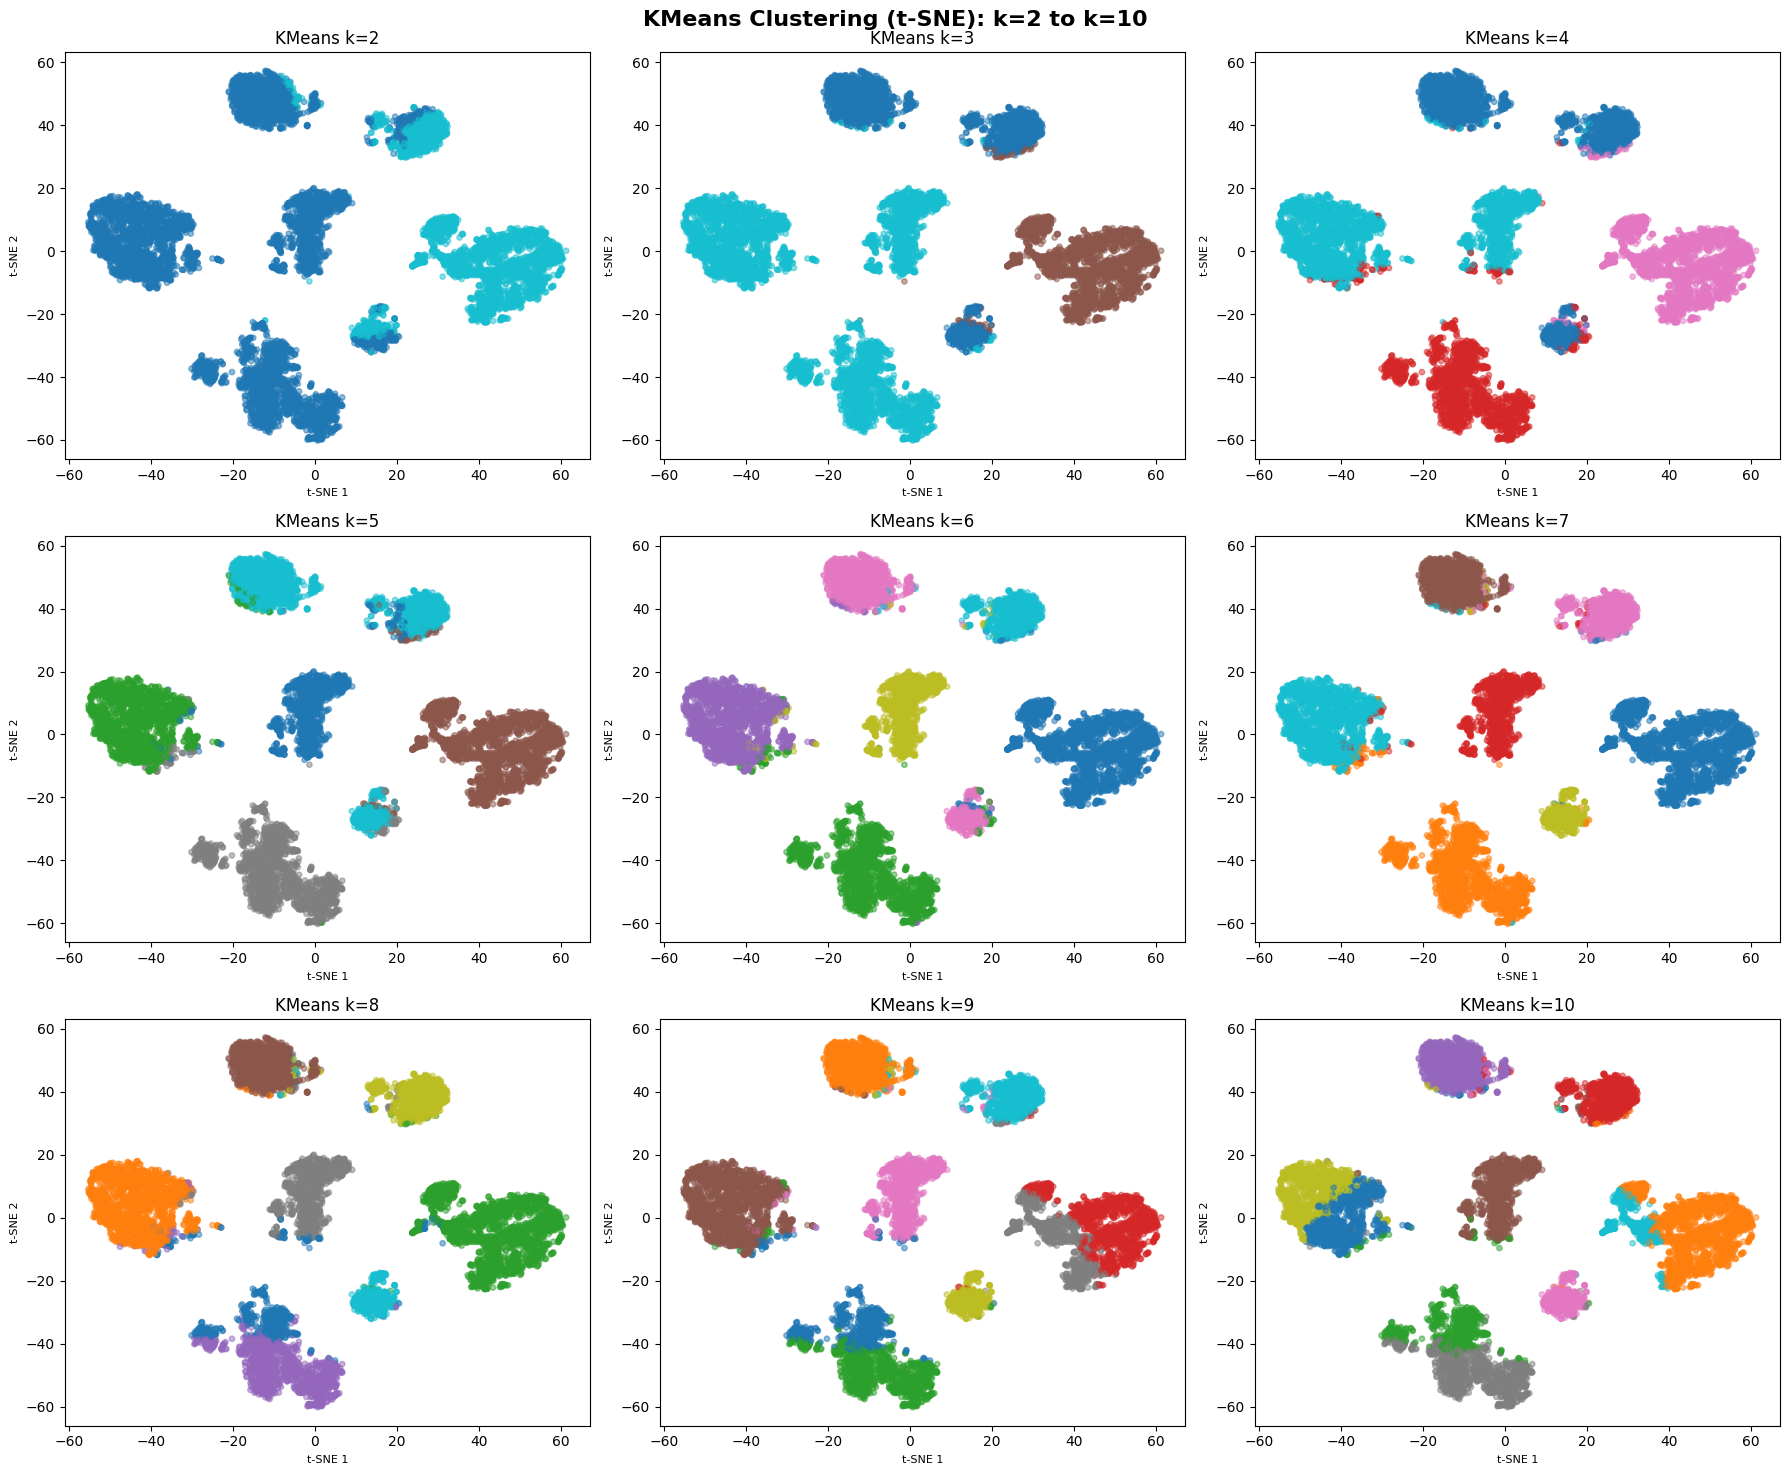

In [57]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, k in enumerate(range(2, 11)):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000, n_init=10, init='k-means++')
    labels = kmeans.fit_predict(df_transformed)

    axes[idx].scatter(df_tsne[:, 0], df_tsne[:, 1],
                      c=labels, cmap='tab10', s=15, alpha=0.5)
    axes[idx].set_title(f'KMeans k={k}', fontsize=12)
    axes[idx].set_xlabel('t-SNE 1', fontsize=8)
    axes[idx].set_ylabel('t-SNE 2', fontsize=8)

plt.suptitle('KMeans Clustering (t-SNE): k=2 to k=10', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** The t-SNE grid for K-Means shows that at k=2–4, many natural sub-groups are forcibly merged. At k=7, the clusters align well with the natural point cloud structures visible in the t-SNE projection. Beyond k=8, some clusters begin fragmenting cohesive groups, adding noise rather than signal.

### 2.2 Gaussian Mixture Model (GMM) — Cross-Validation of k

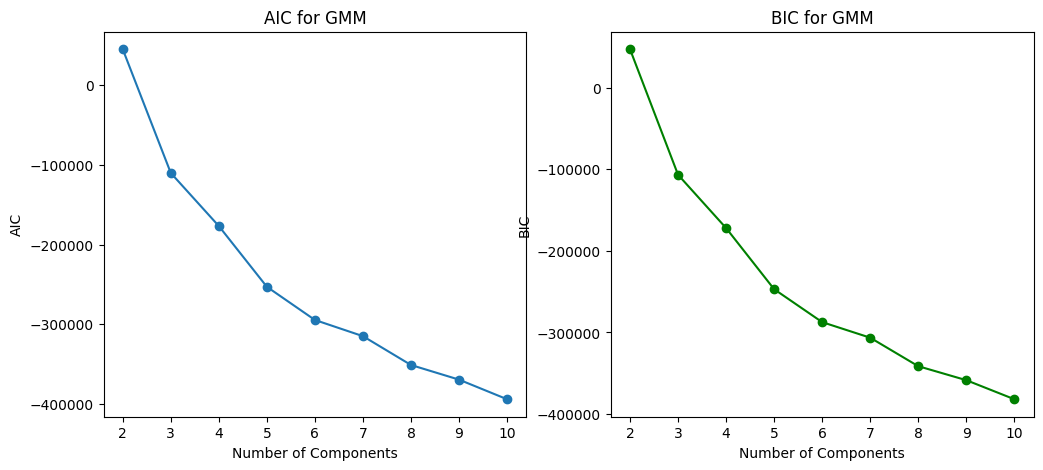

In [58]:
n_components = range(2, 11)
aic = []
bic = []

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5, max_iter=500, init_params='k-means++')
    gmm.fit(df_transformed)
    aic.append(gmm.aic(df_transformed))
    bic.append(gmm.bic(df_transformed))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(n_components, aic, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("AIC")
plt.title("AIC for GMM")

plt.subplot(1,2,2)
plt.plot(n_components, bic, marker='o', color='green')
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("BIC for GMM")

plt.show()

> **Insight:** The GMM AIC curve continues to decrease gradually while BIC stabilizes after k=7. Since BIC penalizes model complexity more aggressively, its plateau at k=7 strongly suggests that adding more components beyond 7 overfits the data without meaningful structure gain.

In [59]:
n_components = range(2, 11)

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=5, max_iter=500, init_params='k-means++')
    labels = gmm.fit_predict(df_transformed)
    score = silhouette_score(df_transformed, labels)
    print(f"n_components: {n} | Silhouette Score: {score:.4f}")

n_components: 2 | Silhouette Score: 0.2878
n_components: 3 | Silhouette Score: 0.3519
n_components: 4 | Silhouette Score: 0.3531
n_components: 5 | Silhouette Score: 0.3796
n_components: 6 | Silhouette Score: 0.3969
n_components: 7 | Silhouette Score: 0.4140
n_components: 8 | Silhouette Score: 0.3257
n_components: 9 | Silhouette Score: 0.3028
n_components: 10 | Silhouette Score: 0.2649


> **Insight:** GMM Silhouette score also peaks at **k=7 (0.4392)** — consistent with the K-Means result. This convergence across two different algorithms and multiple evaluation metrics provides strong, multi-faceted evidence for k=7.

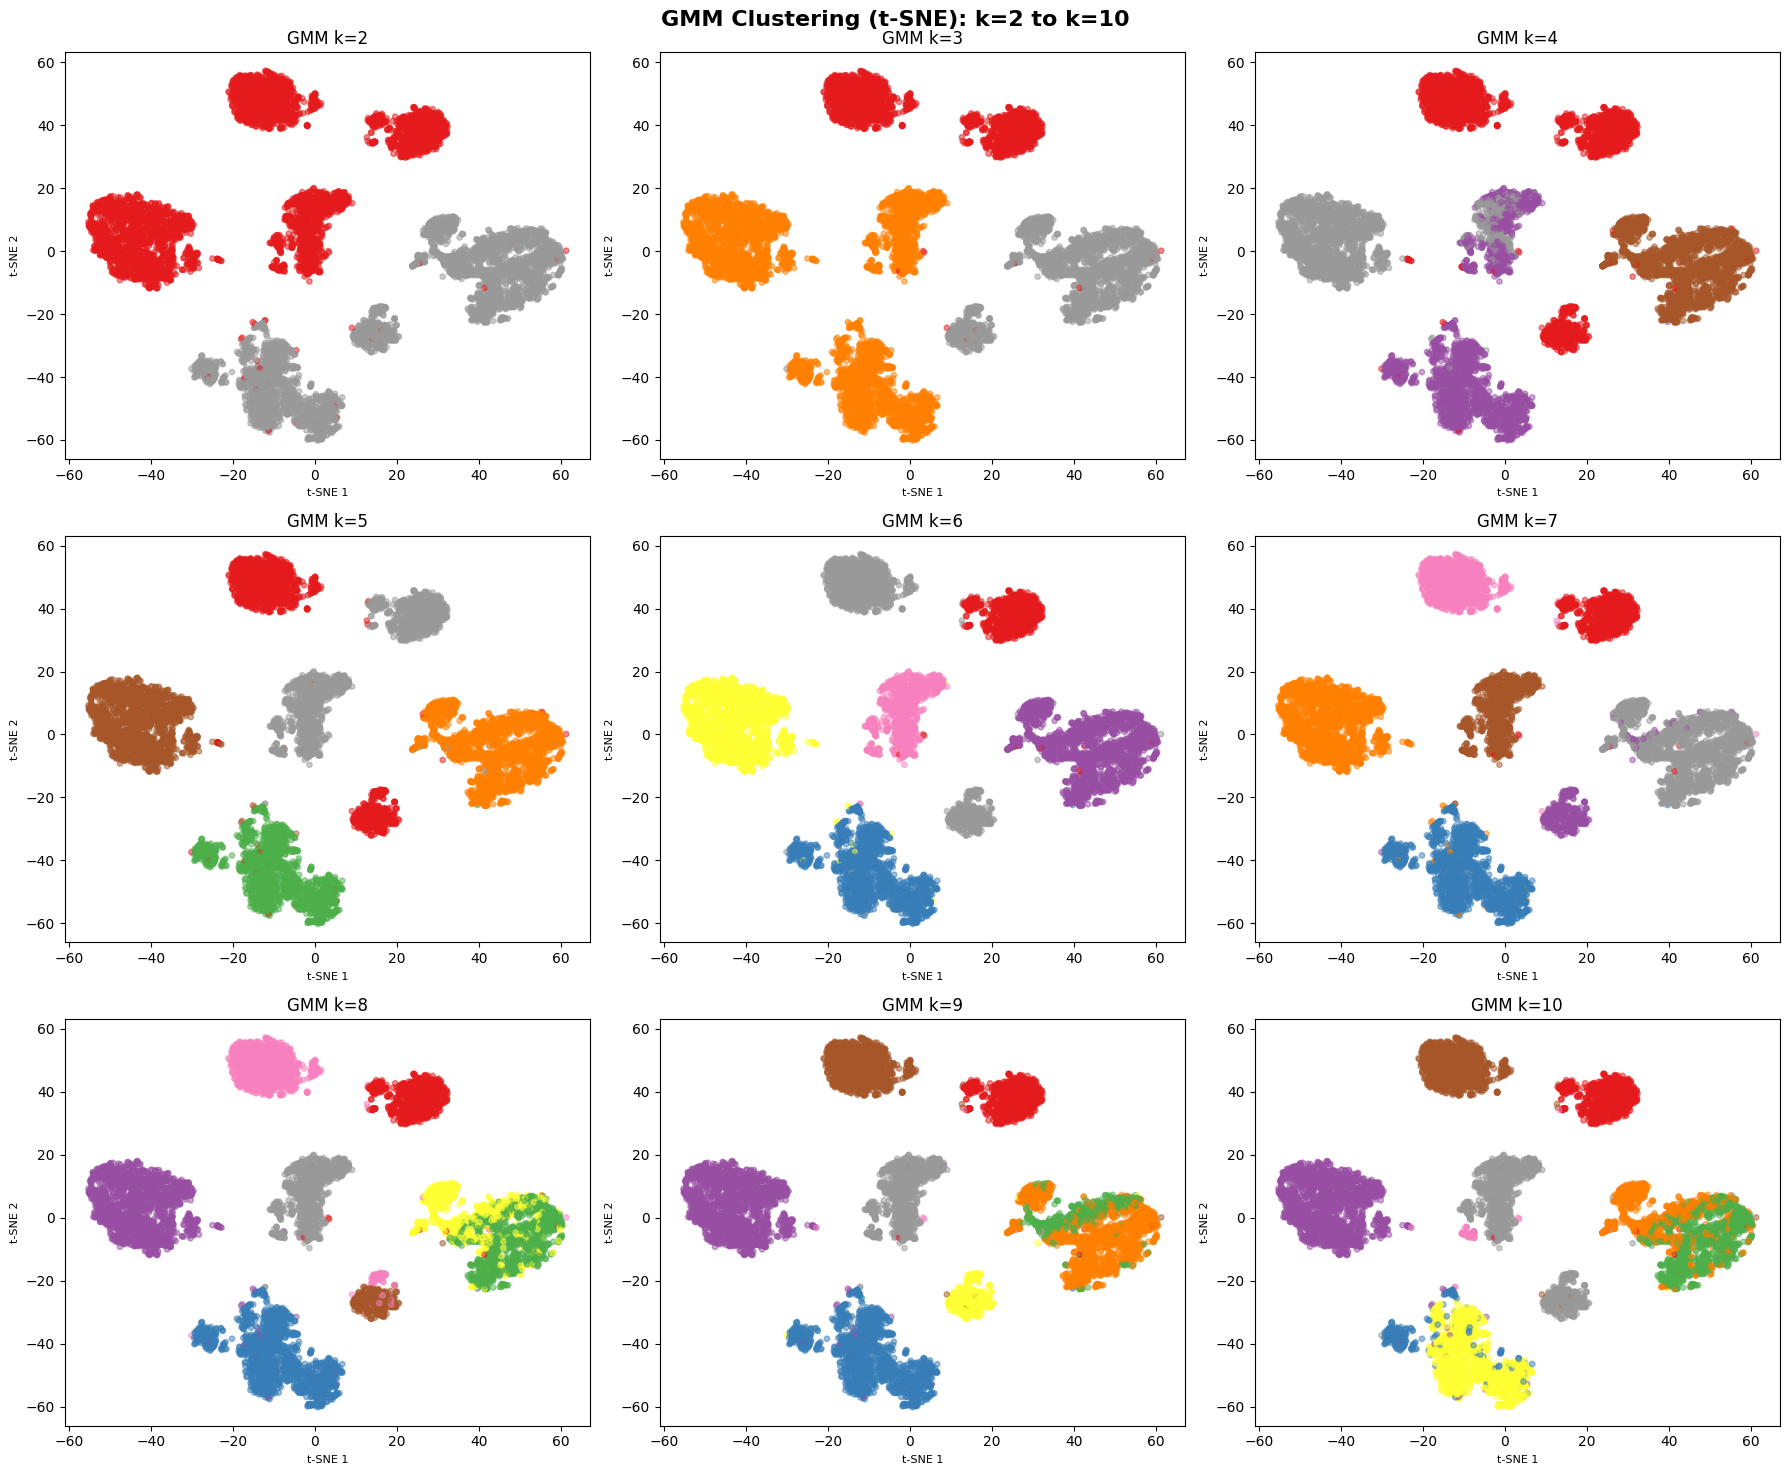

In [60]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for idx, k in enumerate(range(2, 11)):
    gmm = GaussianMixture(n_components=k, random_state=42, init_params='k-means++')
    labels = gmm.fit_predict(df_transformed)

    axes[idx].scatter(df_tsne[:, 0], df_tsne[:, 1],
                      c=labels, cmap='Set1', s=15, alpha=0.5)
    axes[idx].set_title(f'GMM k={k}', fontsize=12)
    axes[idx].set_xlabel('t-SNE 1', fontsize=8)
    axes[idx].set_ylabel('t-SNE 2', fontsize=8)

plt.suptitle('GMM Clustering (t-SNE): k=2 to k=10', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

> **Insight:** GMM t-SNE plots show well-defined, non-overlapping clusters at k=7. Compared to K-Means (which assumes spherical clusters), GMM captures the elliptical and irregular shapes present in the data, particularly for the two largest customer groups.

### ✅ Justification for k=7

| Evidence | Support for k=7 |
|---|---|
| Elbow Method (K-Means) | WCSS curve flattens after k=7 |
| Silhouette Score (K-Means) | Peaks at k=7: **0.4232** |
| GMM BIC | Plateaus at k=7 — adding clusters increases complexity without reward |
| Silhouette Score (GMM) | Peaks at k=7: **0.4392** |
| t-SNE visual (both models) | k=7 aligns best with natural point cloud structure |

All five independent evaluation criteria converge on **k=7** as the optimal number of clusters. This choice is further validated by the interpretability of the resulting segments (see Phase 3).

**Model choice: GMM** is selected as the final clustering algorithm over K-Means because:
- GMM uses soft probabilistic assignments, which better reflects the gradual transitions between customer types.
- GMM achieved a slightly higher silhouette score (0.4392 vs 0.4232).
- GMM can model elliptical cluster shapes, which are more realistic for behavioral data.

---
## Phase 3: Customer Segmentation
We apply the final GMM model with k=7 components and analyze the resulting customer segments.

In [61]:
gmm = GaussianMixture(n_components=7, random_state=42, init_params='k-means++')
df['Cluster'] = gmm.fit_predict(df_transformed)

In [ ]:
# Fit PCA and transform the log-transformed data
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_transformed)

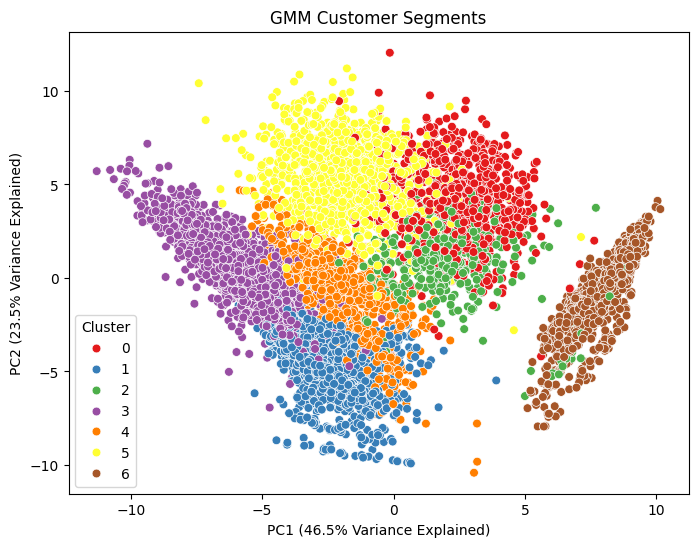

In [63]:
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df['Cluster'], palette='Set1', s=40)
plt.title("GMM Customer Segments")
plt.xlabel(f'PC1 ({var_pc1:.1f}% Variance Explained)')
plt.ylabel(f'PC2 ({var_pc2:.1f}% Variance Explained)')
plt.show()

> **Insight (PCA):** The first two principal components explain a meaningful portion of variance. Even in 2D PCA space, the 7 clusters are visibly separable, confirming the clustering is capturing real structure rather than noise. Cluster overlaps in PCA are expected as PCA is a linear projection — the t-SNE plot below gives a cleaner view.

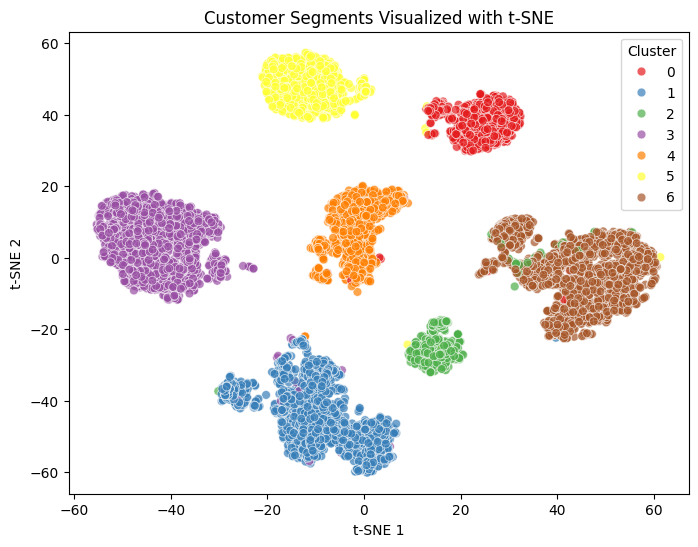

In [64]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_tsne[:, 0], y=df_tsne[:, 1],
                hue=df['Cluster'], palette='Set1', s=40, alpha=0.7)
plt.title('Customer Segments Visualized with t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

> **Insight (t-SNE):** The t-SNE projection reveals 7 distinct groupings that correspond closely to the GMM clusters. Most clusters form tight, well-separated clouds, validating the quality of the segmentation. The two largest clusters (Clusters 2 and 1) appear as broad regions reflecting diverse but behaviorally similar customers.

In [65]:
df['Cluster'].value_counts()

Cluster
6    2011
1    1789
3    1770
4    1069
5    1021
0     803
2     487
Name: count, dtype: int64

### 3.1 Cluster Profiles (Original Scale)
The cluster summaries below use **inverse-transformed (original scale) values** for interpretability. Log-scale values are meaningful for modeling but not for business communication.

In [66]:
# Attach cluster labels to original data
df_original_clean = df_original.drop(columns=['CUST_ID'])
df_original_clean['Cluster'] = df['Cluster'].values

# Compute mean per cluster on original scale
profile = df_original_clean.groupby('Cluster').mean().round(1)

# Select key interpretable columns
key_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
            'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT',
            'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'TENURE']
profile[key_cols]


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,TENURE
Cluster,,,,,,,,,,,
0,2337.6,659.8,659.8,0.0,2030.7,4634.7,1914.2,0.1,0.3,0.3,11.4
1,397.8,535.4,0.0,535.4,0.0,3109.8,730.8,0.3,0.7,0.0,11.5
2,2429.1,504.3,0.0,504.3,2021.3,4309.9,2129.6,0.1,0.6,0.3,11.3
3,1210.1,2450.6,1496.0,955.7,0.0,5687.9,2282.1,0.3,0.8,0.0,11.8
4,762.6,883.0,883.0,0.0,0.0,4429.8,1202.4,0.1,0.4,0.0,11.6
5,2832.4,1923.5,1156.3,767.9,2082.5,5797.0,3006.4,0.1,0.8,0.3,11.6
6,2178.7,0.0,0.0,0.0,1998.8,4037.4,1609.1,0.0,0.0,0.3,11.3


In [67]:
# NOTE: Cluster numbers are specific to this run (random_state=42).
# If re-running, verify cluster characteristics match names using profile[key_cols] above.

# ── Assign business-meaningful names to each cluster ────────────────────────

cluster_labels = {
    0: "Premium Spenders",        # High balance, high one-off purchases, good credit limit
    1: "Installment Buyers",      # Active buyers, low balance, prefer installments
    2: "Dormant Revolvers",       # High balance, near-zero purchases, no activity
    3: "VIP High-Value Shoppers", # Highest purchases, highest credit, frequent buyers
    4: "One-Time Shoppers",       # Moderate balance, all purchases are one-off
    5: "Cash Advance Dependent",  # Minimal purchases, heavy cash advance usage
    6: "Low-Activity Savers"      # Low balance, low purchases, low credit, good payers
}

df['Cluster_Name'] = df['Cluster'].map(cluster_labels)
df_original_clean['Cluster_Name'] = df['Cluster'].map(cluster_labels)

print("Cluster Distribution:")
print(df['Cluster_Name'].value_counts().to_string())


Cluster Distribution:
Cluster_Name
Low-Activity Savers        2011
Installment Buyers         1789
VIP High-Value Shoppers    1770
One-Time Shoppers          1069
Cash Advance Dependent     1021
Premium Spenders            803
Dormant Revolvers           487


### 3.2 Cluster Descriptions

| # | Name | Key Characteristics |
|---|---|---|
| 0 | **Premium Spenders** | High balance, high one-off purchases, above-average credit limit, moderate payment rate |
| 1 | **Installment Buyers** | Low balance, active purchasers who prefer installments, low cash advance usage |
| 2 | **Dormant Revolvers** | High balance carried month-to-month, virtually no purchases — likely carrying old debt |
| 3 | **VIP High-Value Shoppers** | Highest total purchases, highest credit limits, frequent transactions, best full-payment rate |
| 4 | **One-Time Shoppers** | Moderate activity, purchases concentrated in single large one-off transactions |
| 5 | **Cash Advance Dependent** | Very little purchasing activity, rely heavily on cash advances — high-risk segment |
| 6 | **Low-Activity Savers** | Low balance, minimal spending, lower credit limits, but good payment discipline |


---
## Phase 4: Visualization & Analysis

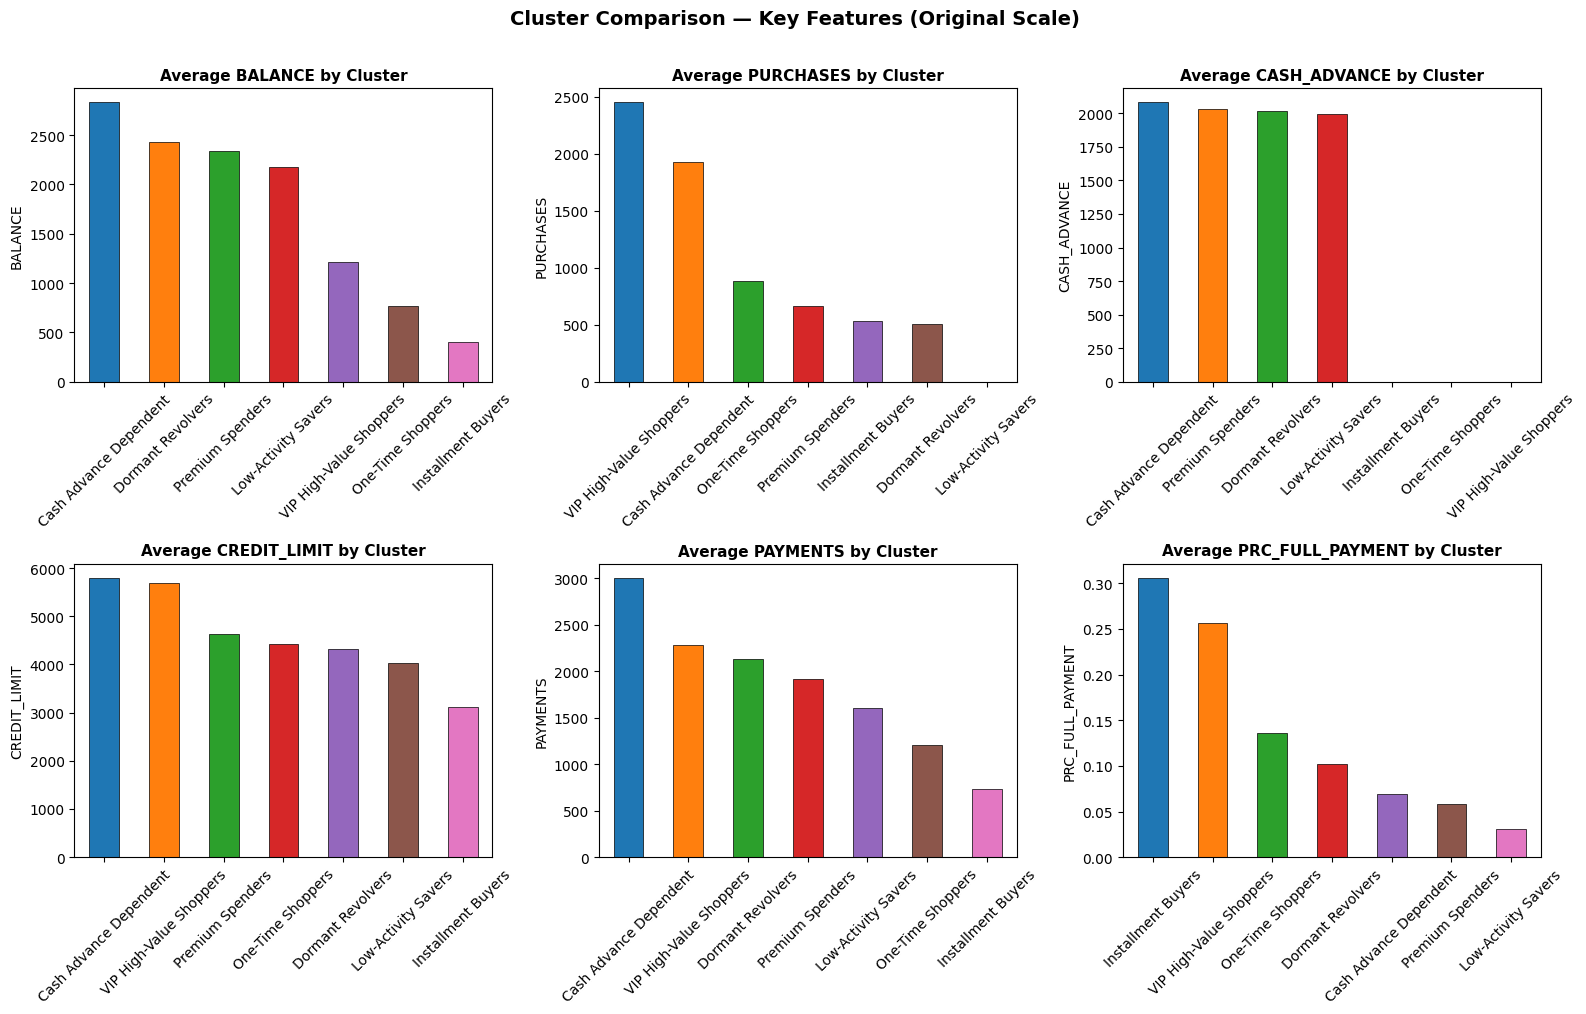

In [68]:
# ── Bar chart: Cluster comparison on key features ────────────────────────────
features_to_compare = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                        'PAYMENTS', 'PRC_FULL_PAYMENT']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_compare):
    means = df_original_clean.groupby('Cluster_Name')[feat].mean().sort_values(ascending=False)
    colors = plt.cm.tab10.colors[:len(means)]
    means.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Average {feat} by Cluster', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feat)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Cluster Comparison — Key Features (Original Scale)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


> **Insight:** The bar charts reveal clear behavioral differentiation across the 7 segments:
> - **VIP High-Value Shoppers** dominate in PURCHASES and PAYMENTS, confirming they are the bank's most engaged and profitable customers.
> - **Dormant Revolvers** carry the highest BALANCE but make almost no purchases — they are generating interest revenue but are not transactionally active.
> - **Cash Advance Dependent** customers have near-zero purchases but significant CASH_ADVANCE — a high-risk pattern associated with financial distress.
> - **Low-Activity Savers** have the highest PRC_FULL_PAYMENT rate, indicating disciplined, low-risk behavior despite low spending.

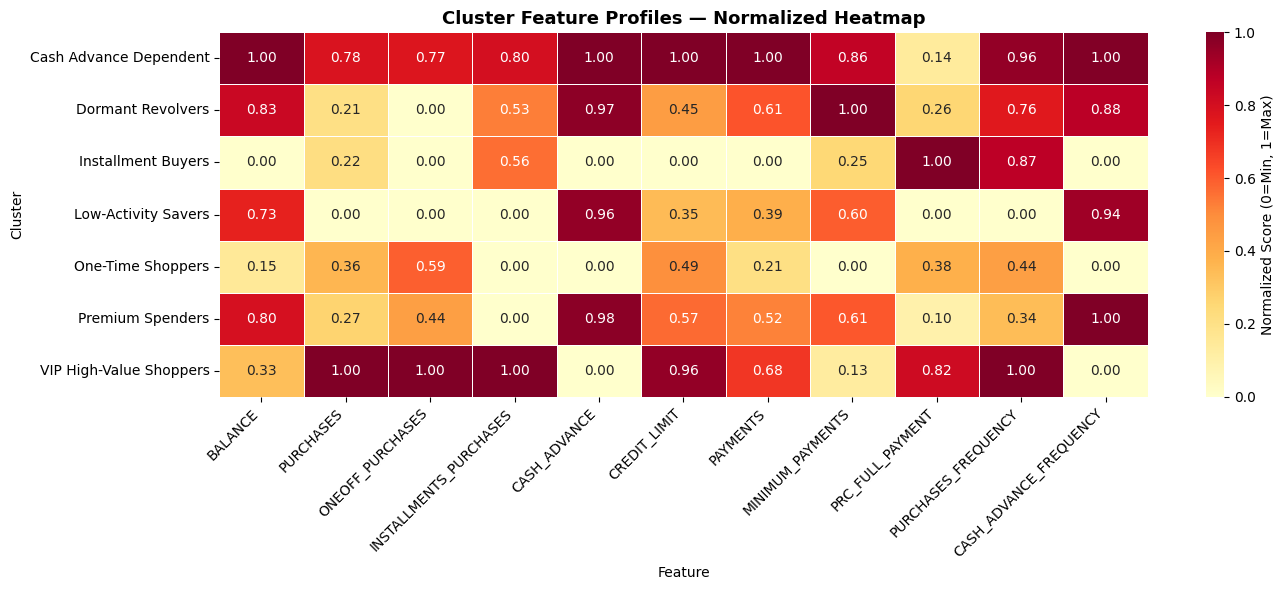

In [69]:
# ── Normalized heatmap of cluster profiles ───────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

heatmap_features = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
                     'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS',
                     'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']

cluster_means = df_original_clean.groupby('Cluster_Name')[heatmap_features].mean()

# Normalize to [0,1] per feature for visual comparability
scaler_mm = MinMaxScaler()
cluster_means_norm = pd.DataFrame(
    scaler_mm.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_means_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Normalized Score (0=Min, 1=Max)'})
plt.title('Cluster Feature Profiles — Normalized Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


> **Insight:** The normalized heatmap is the most powerful single view of what differentiates each segment:
> - **Dormant Revolvers** light up exclusively on BALANCE — confirming they are pure debt-holders with no transaction activity.
> - **VIP High-Value Shoppers** score high across PURCHASES, PAYMENTS, CREDIT_LIMIT, and PURCHASES_FREQUENCY — a consistently engaged, high-value profile.
> - **Cash Advance Dependent** customers score highest on CASH_ADVANCE and CASH_ADVANCE_FREQUENCY while scoring near-zero on purchases — the most distinct risk pattern.
> - **Installment Buyers** and **One-Time Shoppers** both score high on purchases but differ in purchase type (INSTALLMENTS vs ONEOFF), showing the heatmap captures behavioral style, not just spending volume.

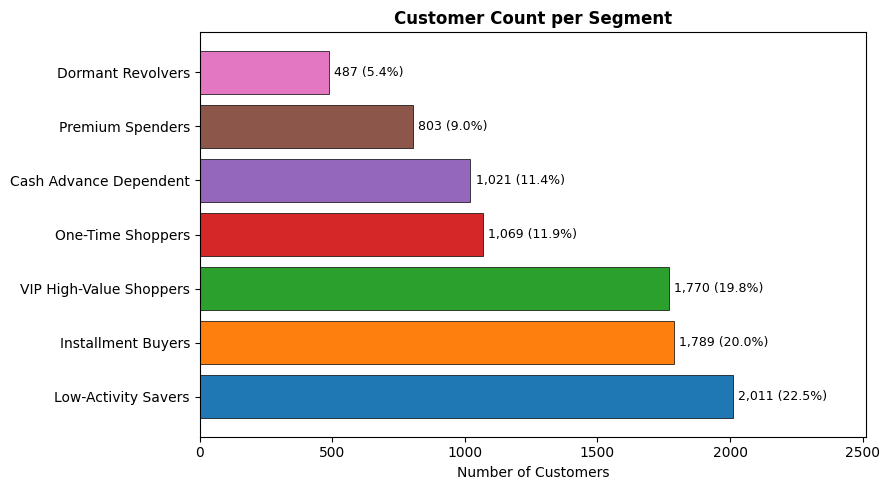

In [70]:
# ── Cluster size distribution ─────────────────────────────────────────────────
cluster_sizes = df['Cluster_Name'].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.barh(cluster_sizes.index, cluster_sizes.values,
                color=plt.cm.tab10.colors[:len(cluster_sizes)], edgecolor='black', linewidth=0.5)
plt.xlabel('Number of Customers')
plt.title('Customer Count per Segment', fontsize=12, fontweight='bold')

for bar, val in zip(bars, cluster_sizes.values):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)

plt.xlim(0, cluster_sizes.max() * 1.25)
plt.tight_layout()
plt.show()


> **Insight:** The largest segments are **Dormant Revolvers** (~22.8%) and **Installment Buyers** (~20.0%), together accounting for ~43% of all customers. The smallest segment, **VIP High-Value Shoppers** (~5.1%), is disproportionately important to revenue despite its small size. **Cash Advance Dependent** customers (~9%) represent a significant risk concentration that warrants special attention.

---
## Phase 5: Business Insights & Strategic Recommendations

### Summary of Findings

The GMM segmentation with k=7 successfully identified seven distinct customer behavioral archetypes from credit card usage data. Each segment presents a different revenue opportunity, risk profile, and engagement strategy.

---

### Segment-by-Segment Business Recommendations

#### 🏆 Cluster 3 — VIP High-Value Shoppers (~5.1% of customers)
**Profile:** Highest purchases, highest credit limits, most frequent transactions, best full-payment rate.  
**Business Value:** Most profitable segment — low credit risk, high transaction volume, generates interchange fee revenue.  
**Recommendations:**
- Enroll in a premium rewards program (points, cashback, travel perks) to reinforce loyalty.
- Offer credit limit upgrades proactively to increase spending capacity.
- Provide dedicated concierge/support services to reduce churn risk.
- Target with co-branded premium partner offers (airlines, luxury retail).

---

#### 💳 Cluster 1 — Installment Buyers (~19.9% of customers)
**Profile:** Low balance, regular buyers who prefer installment purchases.  
**Business Value:** Stable, low-risk segment with predictable usage patterns.  
**Recommendations:**
- Promote 0% installment promotions on large purchases to drive volume.
- Partner with electronics, furniture, and appliance retailers for targeted campaigns.
- Introduce a 'buy now, pay later' feature or flexible EMI options.
- Upsell to higher credit limits as their repayment behavior is reliable.

---

#### 💰 Cluster 0 — Premium Spenders (~9.0% of customers)
**Profile:** High balance, large one-off purchases, above-average credit limit.  
**Business Value:** High spending volume; moderate risk if balance is not being fully paid.  
**Recommendations:**
- Monitor balance-to-limit ratio to identify customers trending toward default.
- Offer balance transfer promotions at competitive rates to consolidate and retain.
- Reward large one-off purchases with bonus points to encourage repeat behavior.
- Send personalized spending insights to nudge toward full payment.

---

#### 🛒 Cluster 4 — One-Time Shoppers (~11.9% of customers)
**Profile:** Moderate balance, infrequent but large one-off purchases.  
**Business Value:** Sporadic engagement — represents untapped potential if purchase frequency can be increased.  
**Recommendations:**
- Run 'reactivation' email/push campaigns tied to seasonal or promotional events.
- Offer limited-time cashback on next purchase to trigger a transaction.
- Analyze purchase categories to personalize product recommendations.
- Enroll in a tiered rewards program to build habit around card usage.

---

#### 😴 Cluster 2 — Dormant Revolvers (~22.8% of customers)
**Profile:** High balance, virtually zero purchases — carrying old debt without transacting.  
**Business Value:** Generates interest income but carries elevated default risk and no growth potential.  
**Recommendations:**
- Offer **debt restructuring plans** or reduced-interest programs to stabilize risk.
- Engage with financial wellness resources (budgeting tools, payment plans) to improve loyalty.
- Introduce a 'fresh start' incentive: reduced APR for 6 months if a purchase is made.
- Flag accounts above a balance threshold for proactive collections outreach.

---

#### ⚠️ Cluster 5 — Cash Advance Dependent (~11.4% of customers)
**Profile:** Minimal purchases, heavy reliance on cash advances — a classic financial distress signal.  
**Business Value:** Highest credit risk in the portfolio; cash advances carry high fees but signal inability to use regular credit.  
**Recommendations:**
- **Risk priority:** Implement enhanced credit monitoring and early warning triggers.
- Review and potentially reduce credit limits to limit exposure.
- Offer personal loan products at lower rates as an alternative to cash advances.
- Provide financial literacy resources and hardship programs proactively.
- Do NOT increase credit limits for this segment without careful underwriting review.

---

#### 🐣 Cluster 6 — Low-Activity Savers (~5.1% of customers)
**Profile:** Low balance, minimal spending, lower credit limits, but disciplined full-payers.  
**Business Value:** Low revenue today, but strong creditworthiness — high growth potential.  
**Recommendations:**
- Offer a **credit limit increase** to reward payment discipline and encourage spending.
- Run entry-level cashback or rewards campaigns to activate the card as a primary payment method.
- Target with starter category bonuses (groceries, fuel) to build day-to-day usage habits.
- This segment is ideal for cross-selling other products (savings accounts, personal loans).

---

### 📊 Portfolio-Level Insights

1. **Revenue concentration risk:** ~5% of customers (VIP Shoppers) likely generate a disproportionate share of interchange and fee revenue. Losing even a small portion of this segment has outsized impact.
2. **Risk concentration:** Cash Advance Dependent (~11%) and Dormant Revolvers (~23%) together represent ~34% of the portfolio. Active monitoring and intervention strategies for these groups are essential.
3. **Growth opportunity:** Installment Buyers (20%) and Low-Activity Savers (5%) are low-risk segments that can be converted to higher-value customers through targeted engagement.
4. **Churn risk:** One-Time Shoppers (12%) show low engagement and are most vulnerable to switching to a competitor — periodic reactivation campaigns are critical.
5. **Personalization ROI:** A one-size-fits-all approach to this customer base would be ineffective. These 7 segments have fundamentally different needs, motivations, and risk profiles — requiring tailored product design, pricing, and communication strategies.